# Advanced Search


## Load Models


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

## Selecting the test sample


In [ ]:
import random
# random.seed(69)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")

test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids_adv
test_seg_ids_adv = random.sample(list(test_seg_ids_adv), 2)

selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

In [ ]:
test_pattern_segment_wise

## Advance pattern Locating


In [ ]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.4
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

In [ ]:
# import numpy as np
# from sklearn.neighbors import NearestNeighbors

# def probability_weighted_dbscan(X, probabilities, eps=0.1, min_samples=2, prob_power=2):
#     """
#     A modified DBSCAN algorithm that incorporates probability weights.
    
#     Parameters:
#     -----------
#     X : array-like, shape (n_samples, n_features)
#         The points to cluster
#     probabilities : array-like, shape (n_samples,)
#         Probability values for each point (0 to 1)
#     eps : float
#         The maximum distance between points to be considered neighbors
#     min_samples : int
#         The number of samples in a neighborhood to be considered a core point
#     prob_power : float
#         Power to raise probabilities to, controlling influence strength
        
#     Returns:
#     --------
#     labels : array, shape (n_samples,)
#         Cluster labels for each point (-1 for noise)
#     """
#     n_samples = X.shape[0]
#     labels = np.full(n_samples, -1)  # Start with all points as noise
    
#     # Calculate probability weights (higher value = more influence)
#     prob_weights = probabilities ** prob_power
    
#     # Scale eps by probability for each point's influence
#     effective_eps = eps * (1 + prob_weights)
    
#     # Build a nearest neighbors model for finding points within variable radii
#     nbrs = NearestNeighbors(radius=np.max(effective_eps))
#     nbrs.fit(X)
    
#     # Track visited points
#     visited = np.zeros(n_samples, dtype=bool)
#     cluster_id = 0
    
#     # Sort points by probability (descending) to process high-probability points first
#     sorted_indices = np.argsort(-probabilities)
    
#     def expand_cluster(point_idx, neighbors, cluster_id):
#         # Assign current point to cluster
#         labels[point_idx] = cluster_id
        
#         # Process each neighbor
#         i = 0
#         while i < len(neighbors):
#             neighbor_idx = neighbors[i]
            
#             # If not visited, mark as visited and process its neighborhood
#             if not visited[neighbor_idx]:
#                 visited[neighbor_idx] = True
                
#                 # Find this neighbor's neighbors with its effective radius
#                 neighbor_neighbors = nbrs.radius_neighbors(
#                     X[neighbor_idx].reshape(1, -1),
#                     radius=effective_eps[neighbor_idx],
#                     return_distance=False
#                 )[0]
                
#                 # If neighbor is also a core point, add its neighbors to processing queue
#                 if len(neighbor_neighbors) >= min_samples:
#                     # Use set operation to avoid duplicates
#                     new_neighbors = set(neighbor_neighbors) - set(neighbors)
#                     neighbors.extend(new_neighbors)
            
#             # If neighbor not yet assigned to a cluster, add it to current cluster
#             if labels[neighbor_idx] == -1:
#                 labels[neighbor_idx] = cluster_id
                
#             i += 1
    
#     # Main clustering loop - process points in order of probability
#     for point_idx in sorted_indices:
#         # Skip if already visited
#         if visited[point_idx]:
#             continue
            
#         visited[point_idx] = True
        
#         # Find neighbors using this point's effective radius
#         point_neighbors = nbrs.radius_neighbors(
#             X[point_idx].reshape(1, -1), 
#             radius=effective_eps[point_idx],
#             return_distance=False
#         )[0]
        
#         # Check if core point
#         if len(point_neighbors) < min_samples:
#             continue  # Not a core point, continue to next point
        
#         # Expand the cluster from this core point
#         expand_cluster(point_idx, list(point_neighbors), cluster_id)
#         cluster_id += 1
    
#     return labels

In [ ]:
from sklearn.cluster import DBSCAN

def cluster_windows(predicted_patterns , probability_threshold , eps = 0.05 , min_samples = 2 , win_width_proportion = 2):
    df = predicted_patterns.copy()
    
    l = (df['Seg_End'].max() - df['Seg_Start'].min()).days
    m = df['Window_Size'].min()
    print("Length of the segment and the min window size: ", l, m)

    # only get the rows that has a probability greater than the probability threshold
    df = df[df['Probability'] > probability_threshold]

    # Initialize a list to store merged clusters from all groups
    cluster_labled_windows = []
    interseced_clusters = []
    
    min_center = df['Center'].min()
    max_center = df['Center'].max()
    min_win_size = df['Window_Size'].min()
    max_win_size = df['Window_Size'].max()

    # Group by 'Chart Pattern' and apply clustering to each group
    for pattern, group in df.groupby('Chart Pattern'):
        # print (pattern)
        # print(group)
        # Clustering
        # centers = group['Center'].values.reshape(-1, 1)
        centers = group[['Center', 'Window_Size','Probability']].values
        column3_probabilities = centers[:, 2]  # Probabilities
        centers = centers[:, :2]  # Only keep the first two columns for clustering
        
        # scaler = MinMaxScaler()
        # normalized = scaler.fit_transform(centers)
        
        # Extract each column
        column1_centers = centers[:, 0]  # Centers
        column2_win_sizes = centers[:, 1]  # Window sizes

        # Normalize each column separately
        # Column 1 normalization
        if min_center < max_center:  # Avoid division by zero
            norm_col1_cen = (column1_centers - min_center) / (max_center - min_center)
        else:
            # If all values are the same, set to constant (e.g., 0 or 1)
            norm_col1_cen = np.ones_like(column1_centers)

        # Column 2 normalization
        # Only normalize if there's variation in column 2
        if min_win_size < max_win_size:  # Avoid division by zero
            norm_col2_win = (column2_win_sizes - min_win_size) / (max_win_size - min_win_size)
        else:
            # If all values are the same, set to constant (e.g., 0 or 1)
            norm_col2_win = np.ones_like(column2_win_sizes)

        # Combine the normalized columns
        normalized = np.column_stack((norm_col1_cen, norm_col2_win))
        # print("Normalized data: ", normalized)
                
        # devide the second column by 10
        normalized[:, 1] = normalized[:, 1] / win_width_proportion
        # print(normalized)
                
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(normalized)
        group['Cluster'] = db.labels_

        # # Replace the DBSCAN call with:
        # labels = probability_weighted_dbscan(
        #     np.column_stack((norm_col1_cen, norm_col2_win)),  # Features
        #     column3_probabilities,                            # Probabilities
        #     eps=eps,                                          # Same eps as DBSCAN
        #     min_samples=min_samples,                          # Same min_samples as DBSCAN
        #     prob_power=2                                      # Adjust influence strength
        # )
        # group['Cluster'] = labels

        cluster_labled_windows.append(group)

        
        # Filter out noise (-1) and group by Cluster
        for cluster_id, cluster_group in group[group['Cluster'] != -1].groupby('Cluster'):

            
            expanded_dates = []
            for _, row in cluster_group.iterrows():

                dates = pd.date_range(row["Start"], row["End"])
                expanded_dates.extend(dates)

            # print("Total expanded dates:", len(expanded_dates))


            # Step 2: Count occurrences of each date
            date_counts = pd.Series(expanded_dates).value_counts().sort_index()

            # Check if any dates overlap with the minimum requirement
            if len(date_counts[date_counts >= 2]) > 0:
                cluster_start = date_counts[date_counts >= 2].index.min()
                cluster_end = date_counts[date_counts >= 2].index.max()
                
                # check if any is Nat
                if pd.isna(cluster_start) or pd.isna(cluster_end):
                    print(f"Cluster {cluster_id} for pattern {pattern} has no valid dates")
                    continue
                
                interseced_clusters.append({
                    'Seg_ID': cluster_group['Seg_ID'].iloc[0],
                    'Symbol': cluster_group['Symbol'].iloc[0],
                    'Chart Pattern': pattern,
                    'Cluster': cluster_id,
                    'Start': cluster_start,
                    'End': cluster_end,
                    'Seg_Start': cluster_group['Seg_Start'].iloc[0],
                    'Seg_End': cluster_group['Seg_End'].iloc[0]
                })
            else:            
                # Or log that this cluster doesn't have sufficient overlap
                print(f"Cluster {cluster_id} for pattern {pattern} has no dates with sufficient overlap")

    if len(cluster_labled_windows) == 0 or len(interseced_clusters) == 0:
        return None,None
    # # Combine all merged clusters into a final DataFrame
    cluster_labled_windows_df = pd.concat(cluster_labled_windows)
    interseced_clusters_df = pd.DataFrame(interseced_clusters)

    # sort by the index 
    cluster_labled_windows_df = cluster_labled_windows_df.sort_index()
    # print(cluster_labled_windows_df)
    # Display the result
    # print(merged_df)
    return cluster_labled_windows_df,interseced_clusters_df

In [ ]:
from utils.patternLocating import plot_patterns_for_segment

for id in test_seg_ids_adv:
    test_seg_id = id
    plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)

In [ ]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)
            
            # convert Seg_Start and Seg_End to datetime
            group.loc[:, 'Seg_Start'] = pd.to_datetime(group['Seg_Start'])
            group.loc[:, 'Seg_End'] = pd.to_datetime(group['Seg_End'])

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            tested_window_sizes = []
            for win_size_proportion in win_size_proportions:
                window_size = seg_len // win_size_proportion
                if window_size < 5:
                    window_size = 5
                elif window_size > 100:
                    window_size = 100
                
                # make sure the win size is a integer
                window_size = int(window_size)
                
                # check if the window size is already tested , because if the size goes below 5 or above 50, it will be set to 10 or 50 respectively
                if window_size in tested_window_sizes:
                    continue
                tested_window_sizes.append(window_size)
                print(f"Tested Win sizes : {tested_window_sizes}")
                
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
                if ohlc_data_segment is None:
                    print("OHLC Data segment is empty")
                    continue   
                
                len_norm=False
                target_len = target_len
                
                # geet th efirst two words of the model_name 
                model_name_parts = model_name.split(' ')
                data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
                data_set_type
                
                if data_set_type == "Length Normed":
                    len_norm=True
                
                win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
                            
                if win_results_df is None:
                    print("Window results dataframe is empty")
                    continue
                win_results_df["Window_Size"] = window_size
                
                win_results_for_each_size.append(win_results_df)
                
            win_results_df_conc = pd.concat(win_results_for_each_size, ignore_index=True)
                
            window_results_list.append(win_results_df_conc)
            
            predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df_conc)
            if predicted_patterns is None:
                print("Predicted patterns dataframe is empty")
            # print("Predicted Patterns :",predicted_patterns)
            cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, eps=eps, min_samples=min_samples,win_width_proportion=win_width_proportion)
            if cluster_labled_windows_df is None or interseced_clusters_df is None:
                print("Clustered windows dataframe is empty")
                continue
                
            located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
            if located_patterns_and_other_info is None:
                print("Located patterns and other info dataframe is empty")
                continue
            # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            
            # drop teh rows of Chart patterns with the name 'No Pattern' , then print how many rows were dropped
            num_no_patterns = len(located_patterns_and_other_info[located_patterns_and_other_info['Chart Pattern'] == 'No Pattern'])
            # if num_no_patterns > 0:
                # print(f"Number of rows dropped for segment ID {seg_id} : {num_no_patterns}")
            located_patterns_and_other_info = located_patterns_and_other_info[located_patterns_and_other_info['Chart Pattern'] != 'No Pattern']

            plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            located_patterns_and_other_info_list.append(located_patterns_and_other_info)
        except:
            print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
            continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df
            

    
    

In [ ]:
located_patterns_and_other_info_dict['Length Normed + Width Aug OHLC_mini_rocket_xgb']

## Evaluate


In [ ]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [ ]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

In [ ]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

In [ ]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict)
figure = all_metrics[1]

## Testing the clusters


In [ ]:
win_results_df_conc

In [ ]:
import importlib
import utils.patternLocating

importlib.reload(utils.patternLocating)


In [ ]:
from utils.patternLocating import plot_patterns_for_segment

test_seg_id = test_seg_ids_adv[0]
plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)

In [ ]:
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections

predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df_conc)
if predicted_patterns is None:
    print("Predicted patterns dataframe is empty")
# print("Predicted Patterns :",predicted_patterns)
cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, eps=eps, min_samples=min_samples,win_width_proportion=win_width_proportion)
if cluster_labled_windows_df is None or interseced_clusters_df is None:
    print("Clustered windows dataframe is empty")
    # continue
    
located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
if located_patterns_and_other_info is None:
    print("Located patterns and other info dataframe is empty")
    # continue
# plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)

In [ ]:
cluster_labled_windows_df

In [ ]:
x_end = predicted_patterns['Center'].max() + 10
y_end = predicted_patterns['Window_Size'].max() + 10

for pattern, group in cluster_labled_windows_df.groupby('Chart Pattern'):
    plt.figure(figsize=(10, 6))
    
    # Use the Probability column to determine point sizes
    # Multiply by a scaling factor to make the difference more visible
    point_sizes = (group['Probability'] ** 5) * 1000 # Adjust the multiplier as needed
    
    plt.scatter(
        group['Center'], 
        group['Window_Size'], 
        c=group['Cluster'], 
        s=point_sizes,  # Size based on probability
        cmap='viridis', 
        alpha=0.5
    )
    
    plt.title(f'Window Size and Center for {pattern}')
    plt.xlabel('Center')
    plt.ylabel('Window Size')
    plt.colorbar(label='Cluster')
    
    # Add legend or note about point sizes
    plt.figtext(0.15, 0.02, "Point size represents probability", ha="center")
    
    # Set axis ranges
    plt.xlim(0, x_end)
    plt.ylim(0, y_end)

    plt.show()

In [ ]:
x_start = predicted_patterns['Center'].min()
x_end = predicted_patterns['Center'].max() 
y_start = predicted_patterns['Window_Size'].min()
y_end = predicted_patterns['Window_Size'].max()

for pattern, group in cluster_labled_windows_df.groupby('Chart Pattern'):
    plt.figure(figsize=(10, 6))
    plt.scatter(
        ((group['Center'] - x_start)/(x_end - x_start)), 
        ((group['Window_Size'] - y_start)/(y_end - y_start))/10, 
        c=group['Cluster'], cmap='viridis', alpha=0.5
    )
    plt.title(f'Window Size and Center for {pattern}')
    plt.xlabel('Center')
    plt.ylabel('Window Size')
    plt.colorbar(label='Cluster')
    
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

In [ ]:
x_end = predicted_patterns['Center'].max() +10
y_end = predicted_patterns['Window_Size'].max() +10
for pattern, group in cluster_labled_windows_df.groupby('Chart Pattern'):
    plt.figure(figsize=(10, 6))
    plt.scatter(group['Center'], group['Window_Size'], c=group['Cluster'], cmap='viridis', alpha=0.5)
    plt.title(f'Window Size and Center for {pattern}')
    plt.xlabel('Center')
    plt.ylabel('Window Size')
    plt.colorbar(label='Cluster')
    
    # 👇 Set your custom axis ranges here
    plt.xlim(0, x_end)  # e.g., plt.xlim(0, 100)
    plt.ylim(0, y_end)  # e.g., plt.ylim(0, 150)

    plt.show()


In [ ]:
window_results_list[0]

In [ ]:
import sys

from tqdm import tqdm

from formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import cluster_windows, get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days

            window_size = seg_len // win_size_proportion
            # print(f"Win size : {window_size}")
            if window_size < 10:
                window_size = 10
            # elif window_size > 30:
            #     window_size = 30
                
            ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
            if ohlc_data_segment is None:
                print("OHLC Data segment is empty")
                continue   
            
            len_norm=False
            target_len = target_len
            
            # geet th efirst two words of the model_name 
            model_name_parts = model_name.split(' ')
            data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
            data_set_type
            
            if data_set_type == "Length Normed":
                len_norm=True
            
            win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
            
            if win_results_df is None:
                print("Window results dataframe is empty")
                continue
            window_results_list.append(win_results_df)
            # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
            predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
            if predicted_patterns is None:
                print("Predicted patterns dataframe is empty")
            # print("Predicted Patterns :",predicted_patterns)
            cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
            if cluster_labled_windows_df is None or interseced_clusters_df is None:
                print("Clustered windows dataframe is empty")
                continue
            located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
            if located_patterns_and_other_info is None:
                print("Located patterns and other info dataframe is empty")
                continue
            # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
            
            
            
            located_patterns_and_other_info_list.append(located_patterns_and_other_info)
        except:
            print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
            continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df
    


# Advanced Search - Larger cover Smaller method


## Load Models


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

Available models:
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_rocket_xgb


## Selecting the test sample


In [12]:
import random
# random.seed(69)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")
# convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

test_seg_ids_adv = test_pattern_segment_wise['Seg_ID'].unique()
# select random 100 seg ids from the test_seg_ids_adv
test_seg_ids_adv = random.sample(list(test_seg_ids_adv), 100)

selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(np.int64(117), 100)

## Advance pattern Locating


In [13]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.0
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Double Bottom Pattern Start :  2024-12-18 00:00:00 Pattern End :  2025-01-13 00:00:00
Pattern Name :  Double Bottom Pattern Start :  2024-10-25 00:00:00 Pattern End :  2024-10-31 00:00:00


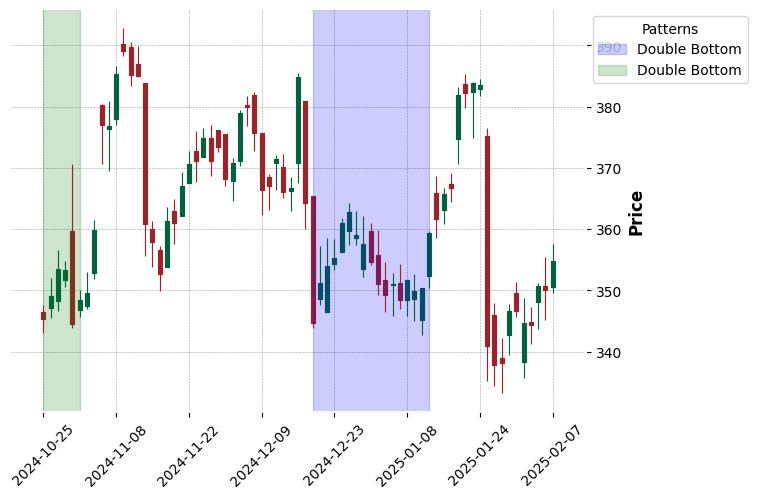

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Double Bottom Pattern Start :  2022-01-24 00:00:00 Pattern End :  2022-02-24 00:00:00


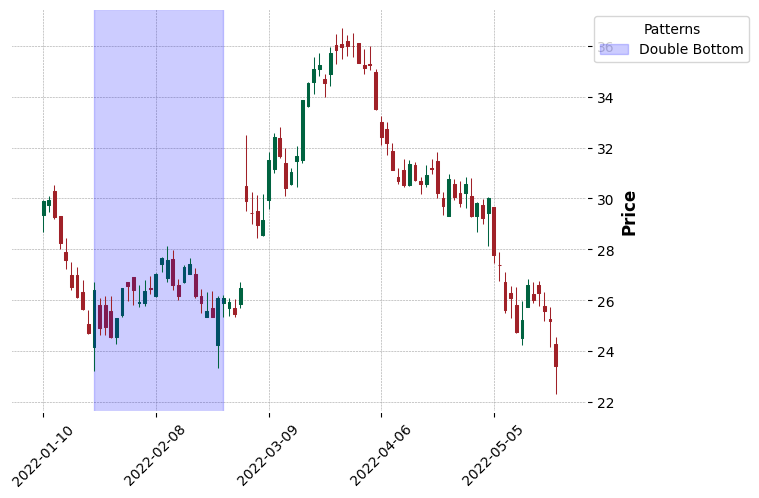

Pattern Name :  Flag, high and tight Pattern Start :  2020-03-18 00:00:00 Pattern End :  2020-04-16 00:00:00


/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


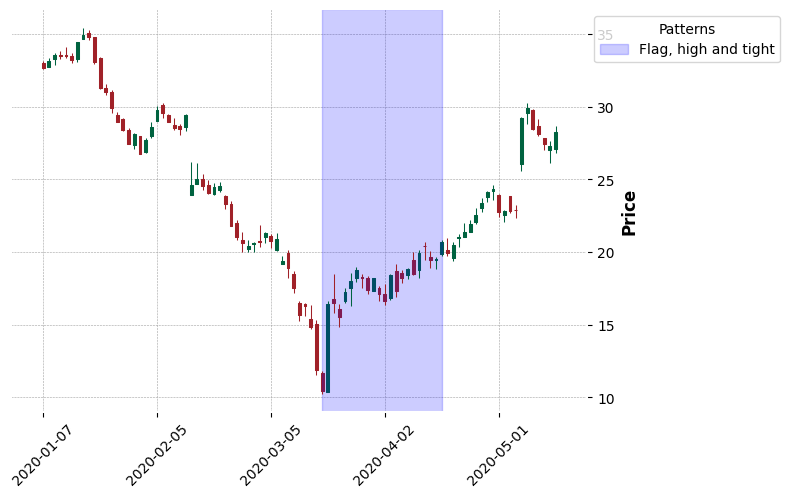

/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_Start'] = pd.to_datetime(group['Seg_Start'])
/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/patternLocating.py:214: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Seg_End'] = pd.to_datetime(group['Seg_End'])


Pattern Name :  Head-and-shoulders bottom Pattern Start :  2022-05-20 00:00:00 Pattern End :  2022-07-18 00:00:00


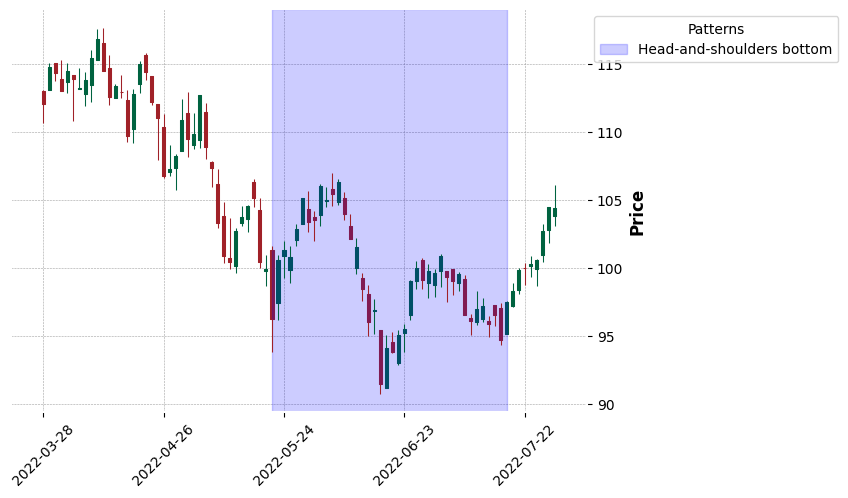

In [14]:
from utils.patternLocating import plot_patterns_for_segment

plot_count1 = 4

for id in test_seg_ids_adv:
    if plot_count1 >0:
        test_seg_id = id
        plot_patterns_for_segment(test_seg_id , test_pattern_segment_wise)
        plot_count1 -= 1

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   12.9s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:   18.5s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    6.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.3s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    6.5s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    6.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=1

Double Bottom  :
    Clustered Windows :


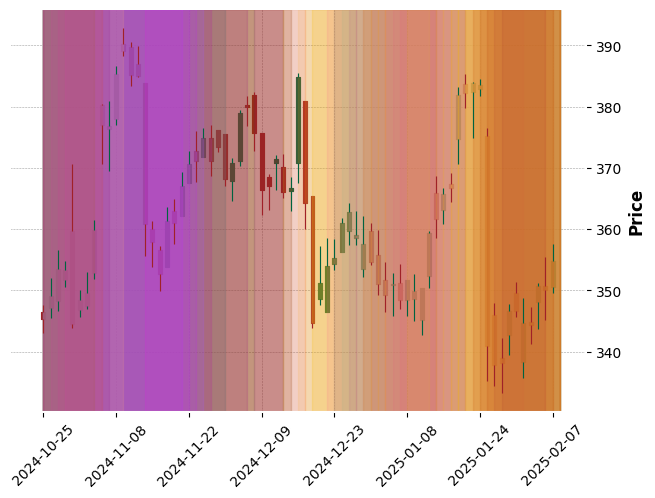

    Finalized Section :


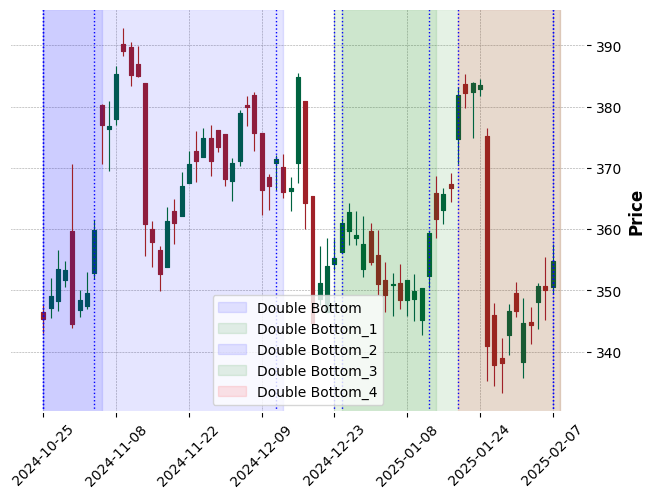

Double Top  :
    Clustered Windows :


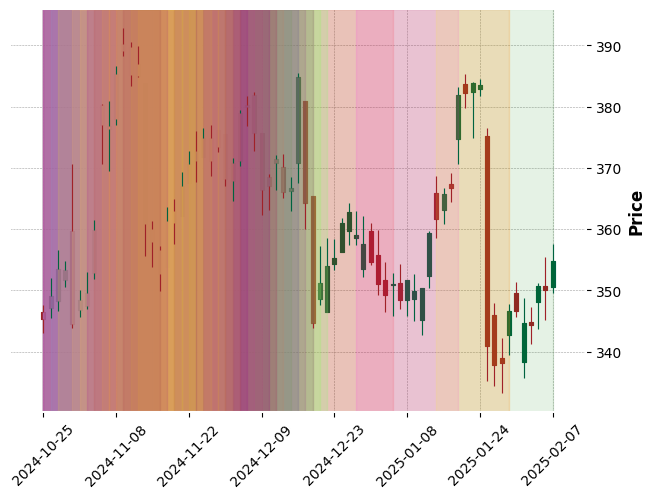

    Finalized Section :


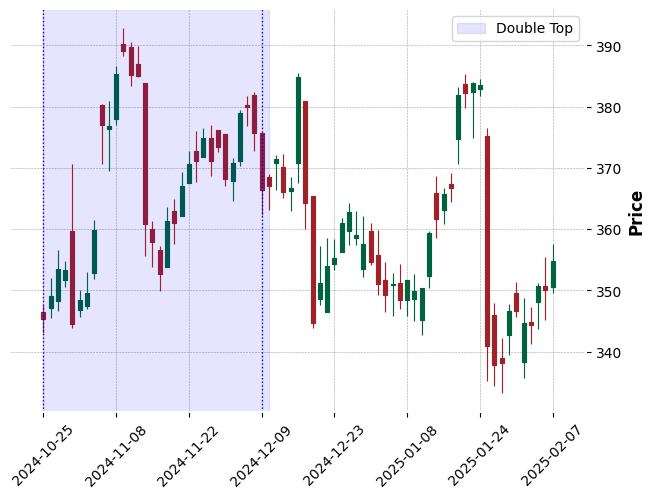

Head-and-shoulders bottom  :
    Clustered Windows :


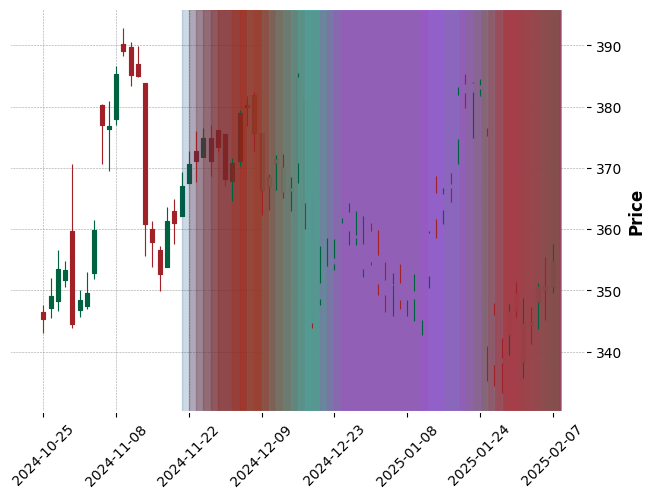

    Finalized Section :


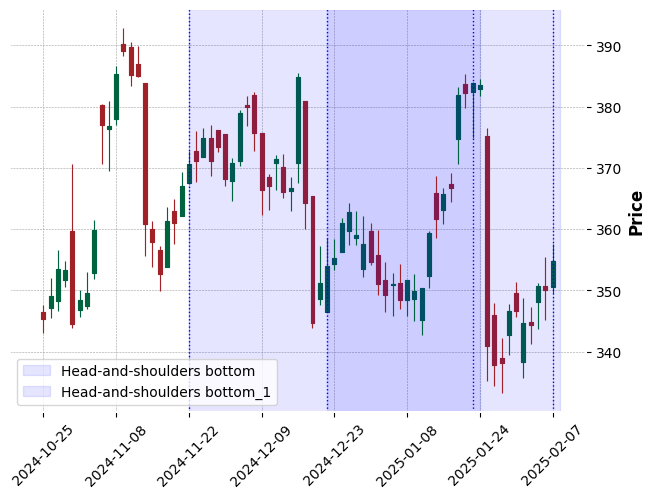

Head-and-shoulders top  :
    Clustered Windows :


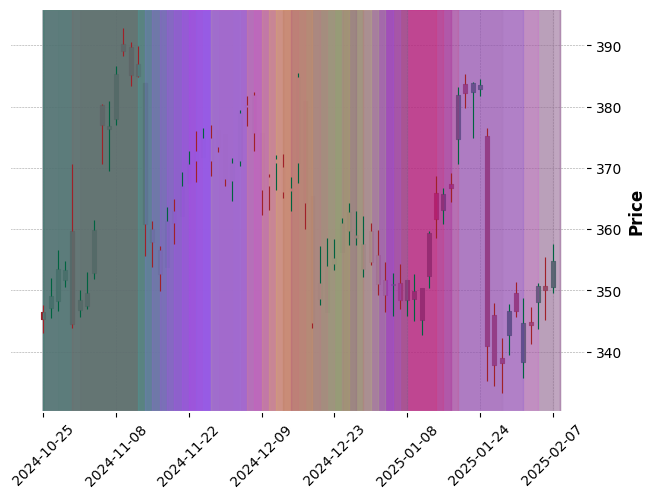

    Finalized Section :


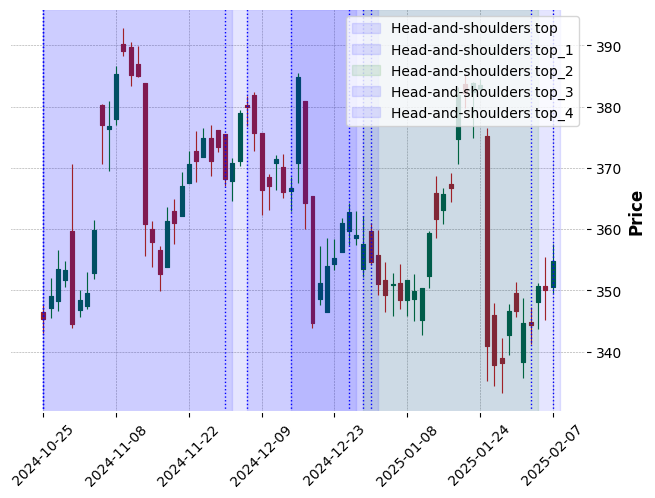

No Pattern  :
    Clustered Windows :


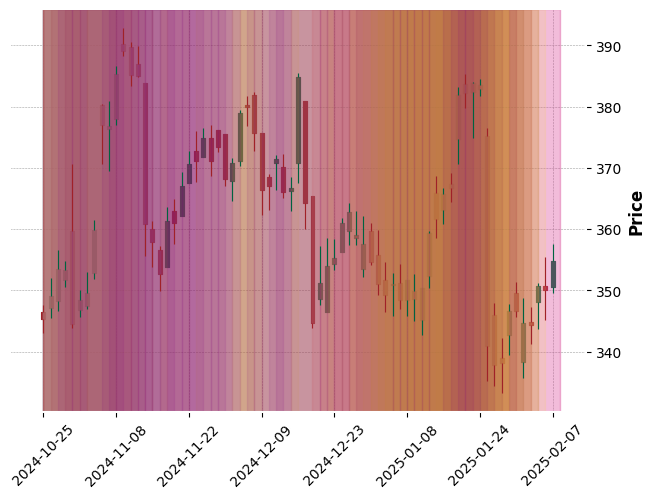

    Finalized Section :


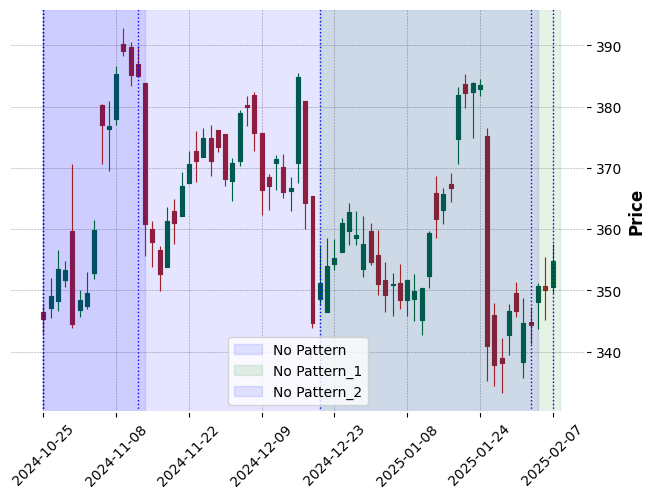

Triangle, symmetrical  :
    Clustered Windows :


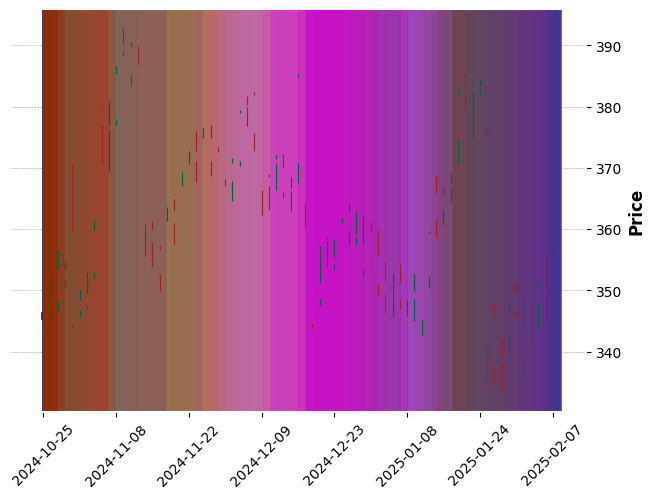

    Finalized Section :


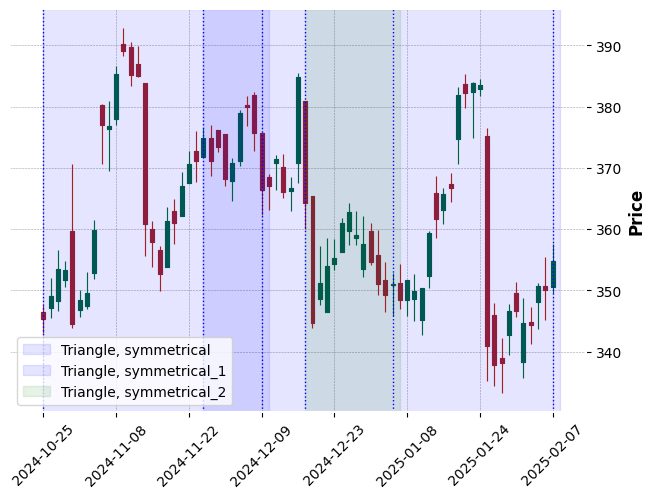

Processing test segments:   1%|          | 1/100 [01:15<2:04:20, 75.36s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done  92 out of  92 | elapsed:    9.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.9s
[Parallel(n_jobs=16)]: Done  92 out of  92 | elapsed:    9.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done  92 out of  92 | elapsed:    9.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done  92 out of  92 | elapsed:    9.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

Double Bottom  :
    Clustered Windows :


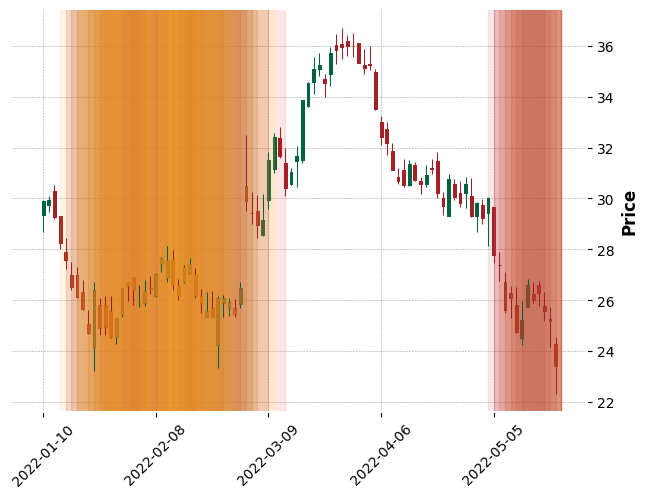

    Finalized Section :


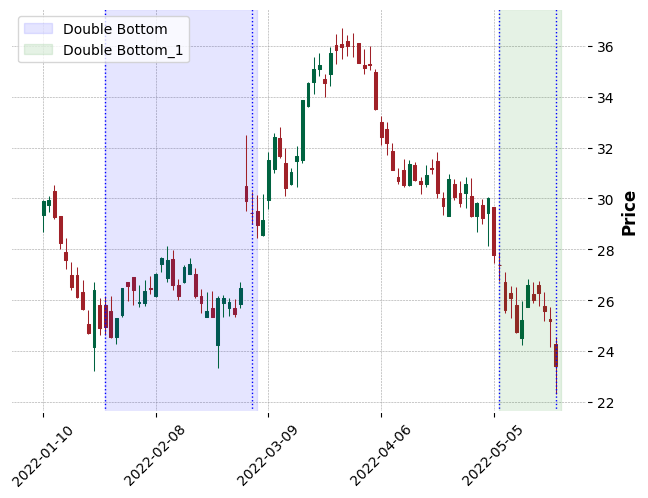

Double Top  :
    Clustered Windows :


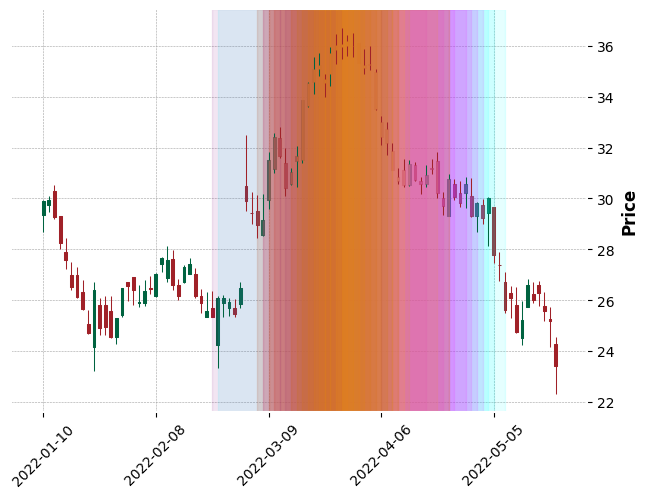

    Finalized Section :


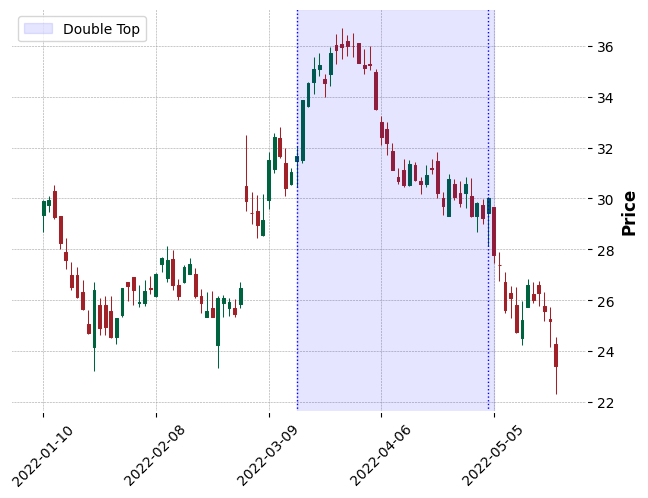

Flag, high and tight  :
    Clustered Windows :


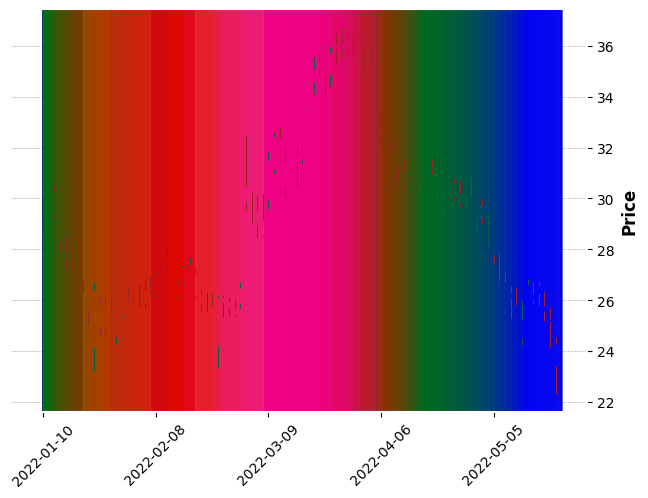

    Finalized Section :


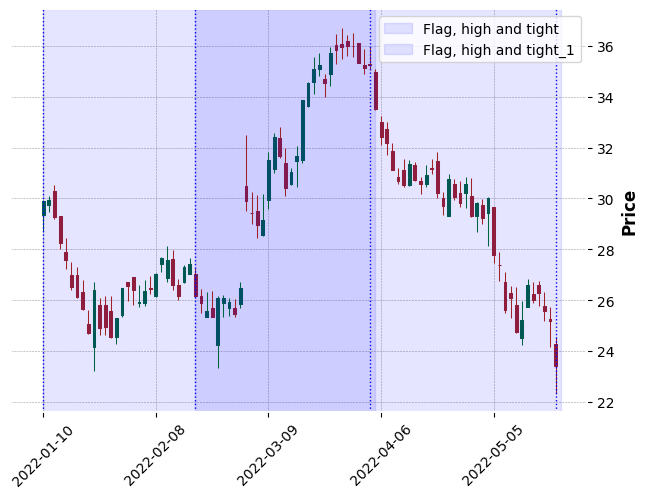

Head-and-shoulders bottom  :
    Clustered Windows :


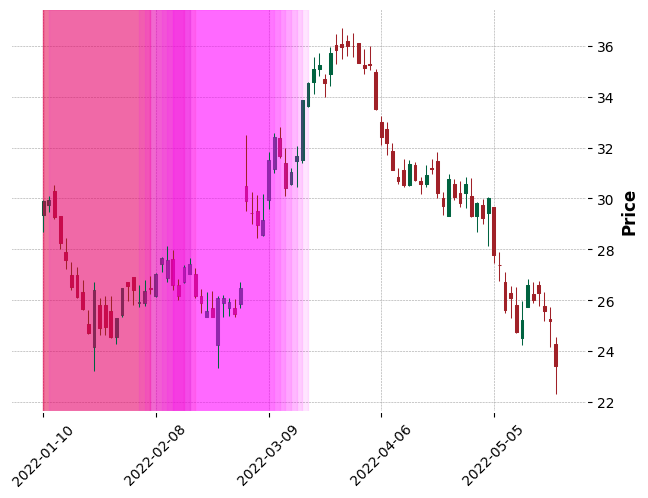

    Finalized Section :


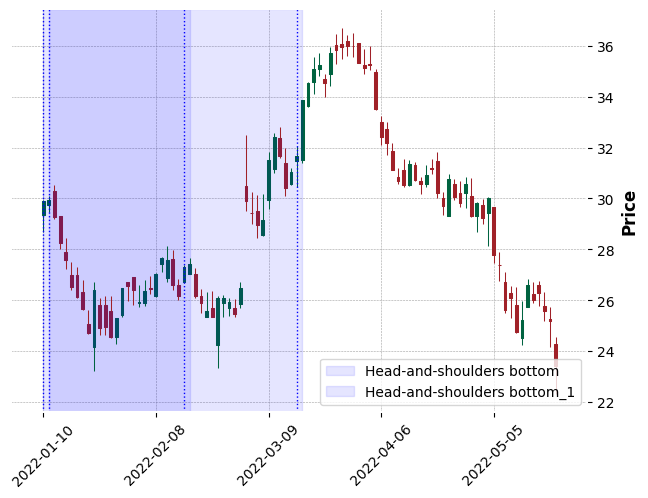

Head-and-shoulders top  :
    Clustered Windows :


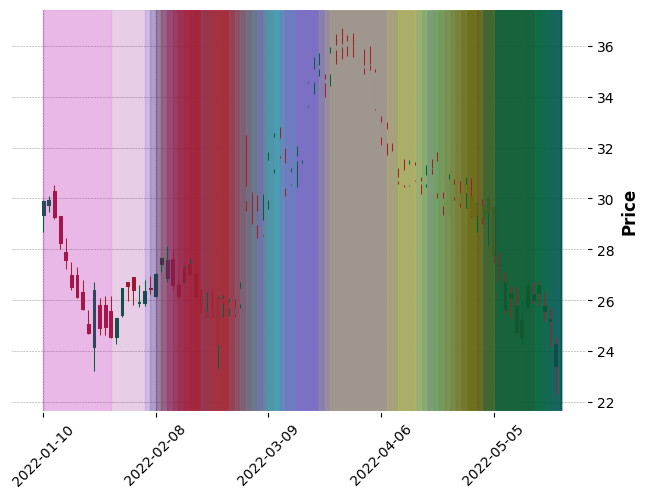

    Finalized Section :


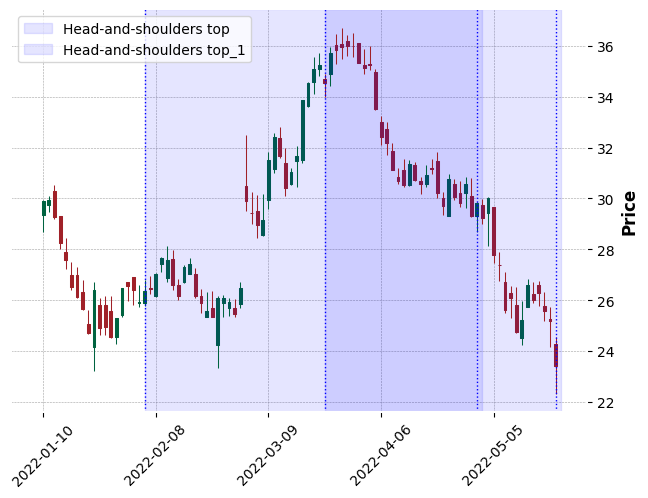

No Pattern  :
    Clustered Windows :


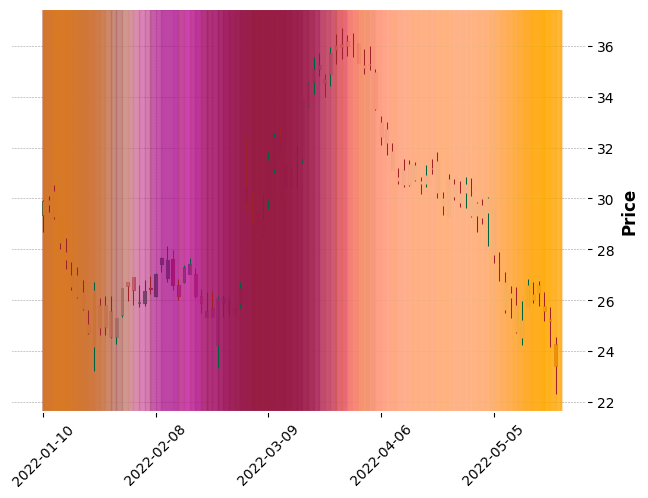

    Finalized Section :


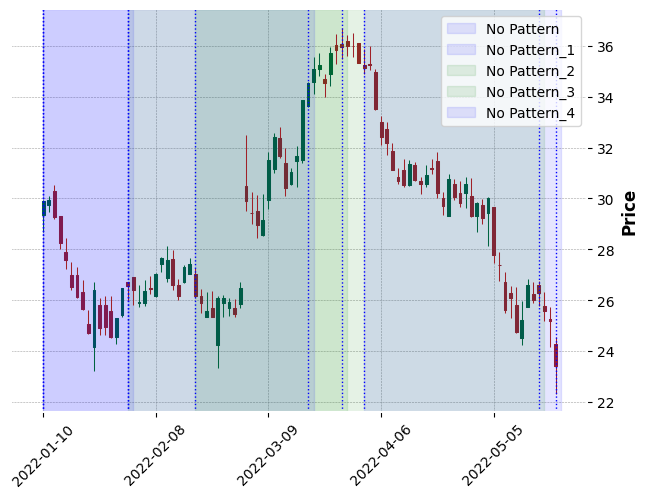

Triangle, symmetrical  :
    Clustered Windows :


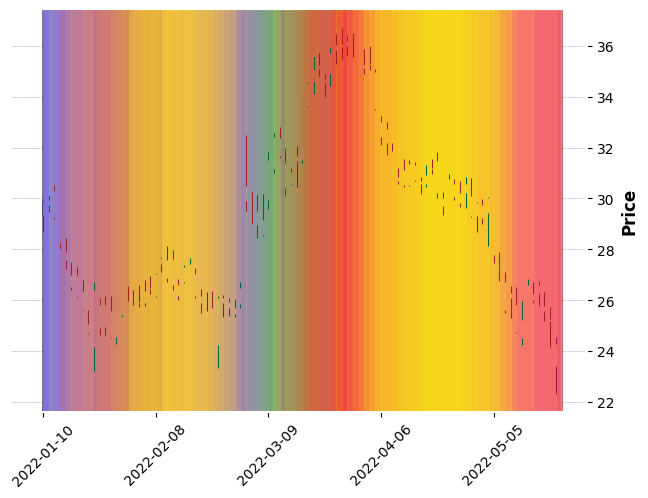

    Finalized Section :


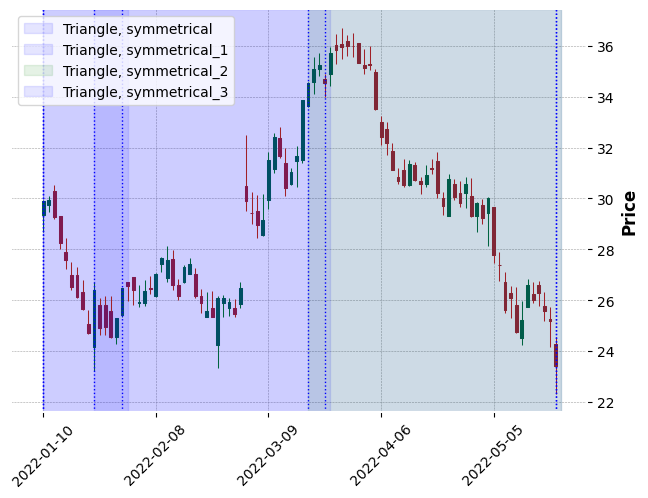

Processing test segments:   2%|▏         | 2/100 [02:47<2:19:19, 85.30s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:    8.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:    9.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:    9.4s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done  91 out of  91 | elapsed:    8.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

Double Bottom  :
    Clustered Windows :


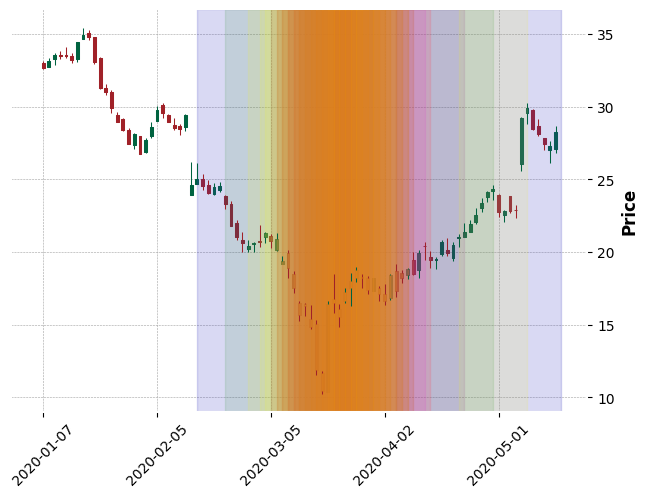

    Finalized Section :


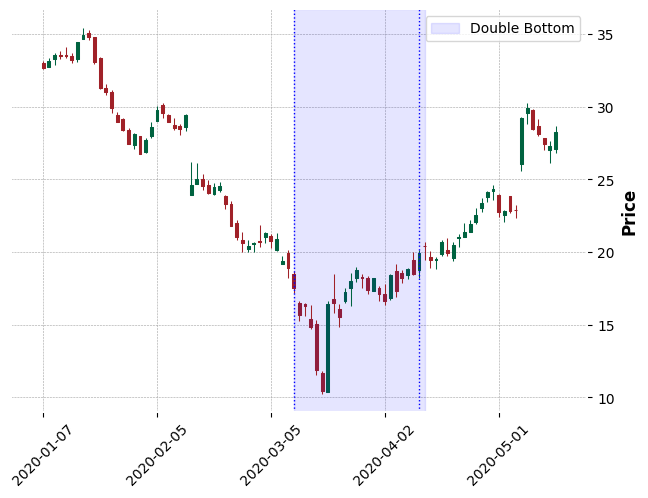

Double Top  :
    Clustered Windows :


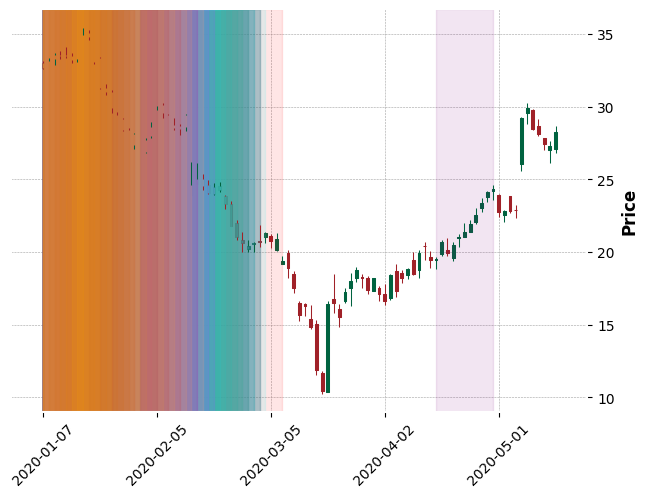

    Finalized Section :


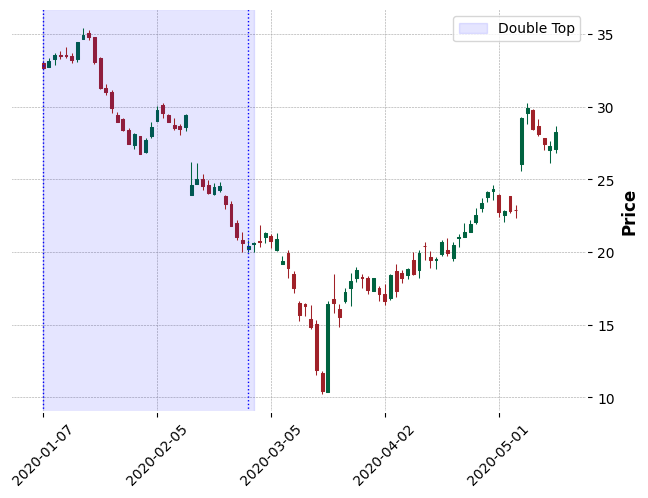

Flag, high and tight  :
    Clustered Windows :


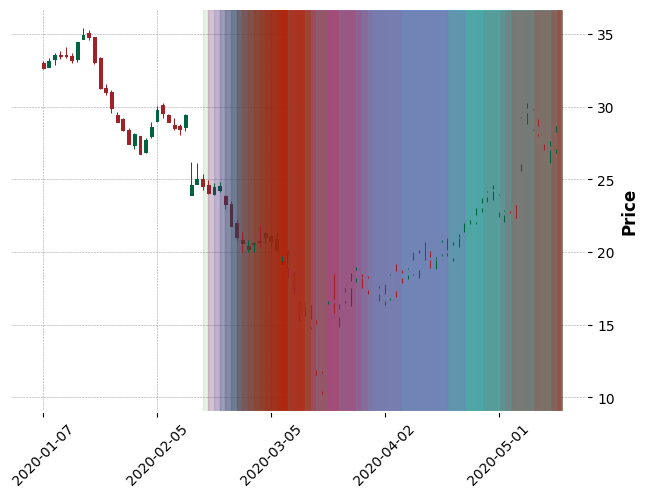

    Finalized Section :


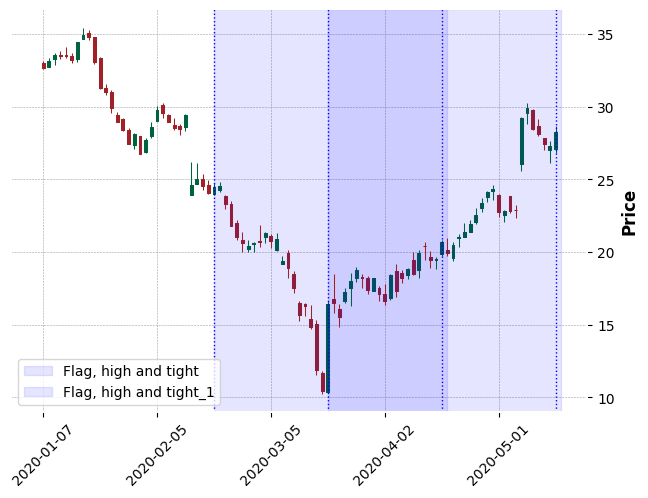

Head-and-shoulders bottom  :
    Clustered Windows :


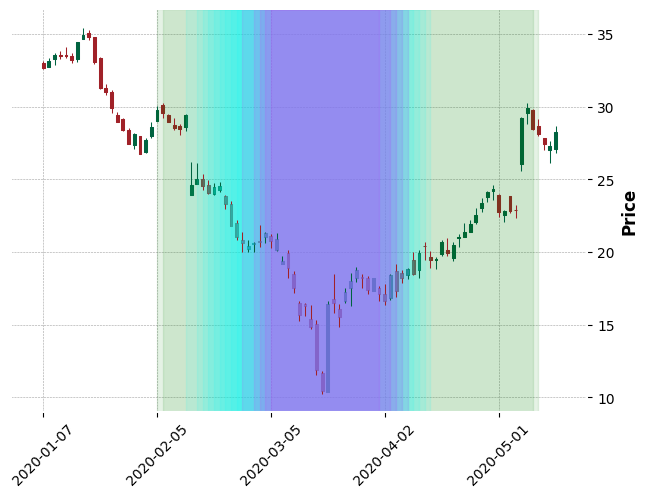

    Finalized Section :


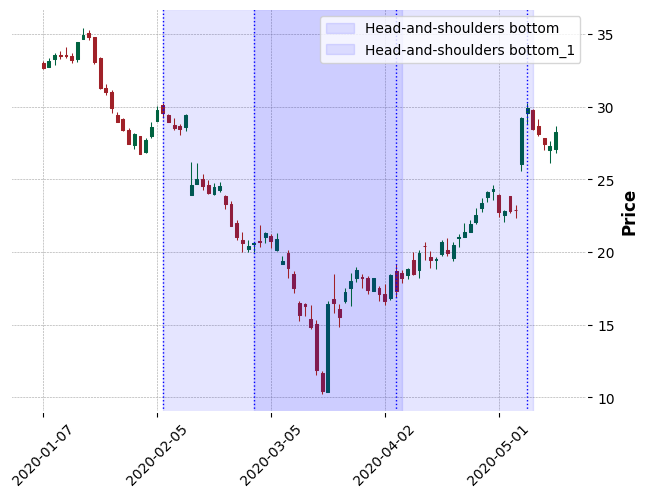

Head-and-shoulders top  :
    Clustered Windows :


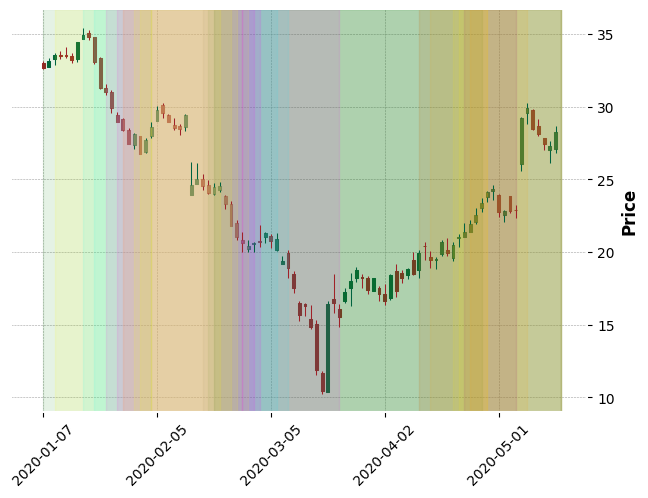

    Finalized Section :


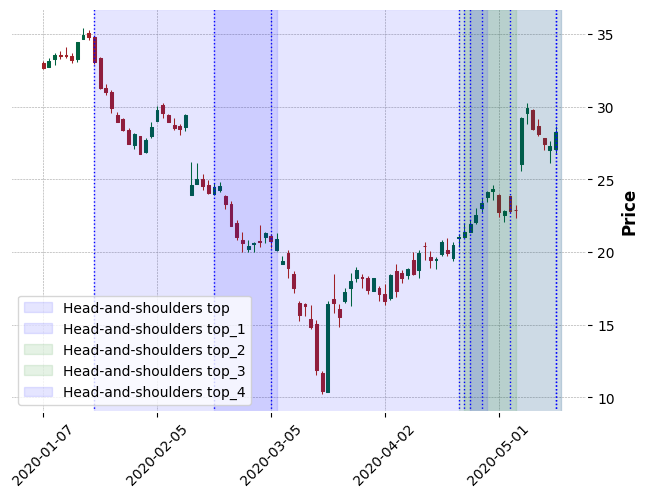

No Pattern  :
    Clustered Windows :


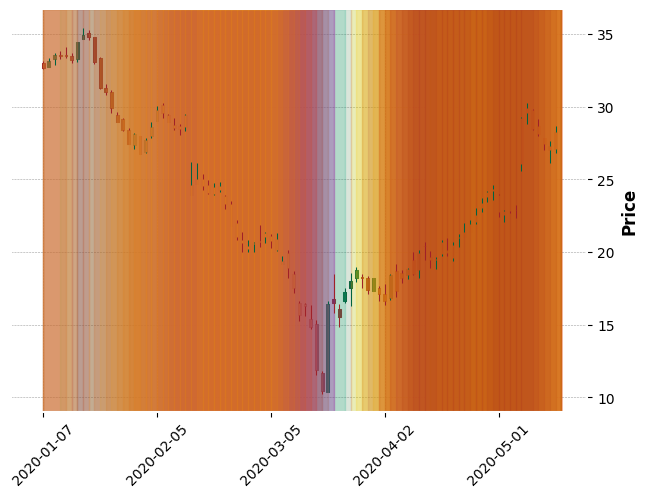

    Finalized Section :


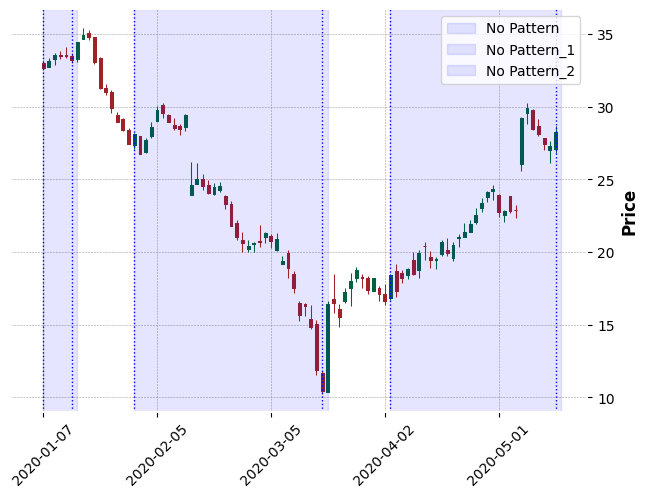

Triangle, symmetrical  :
    Clustered Windows :


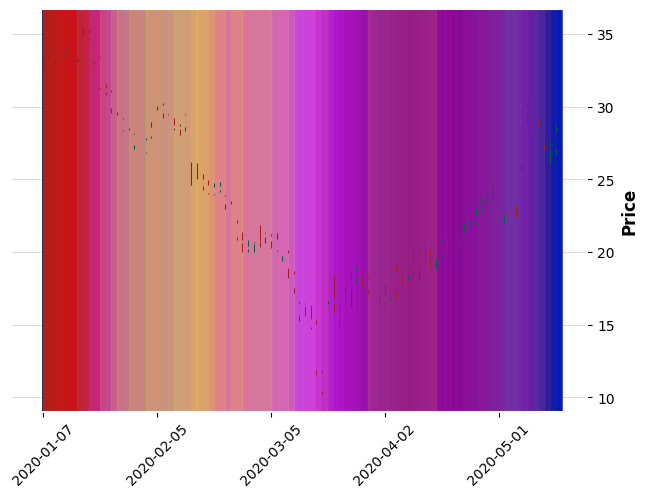

    Finalized Section :


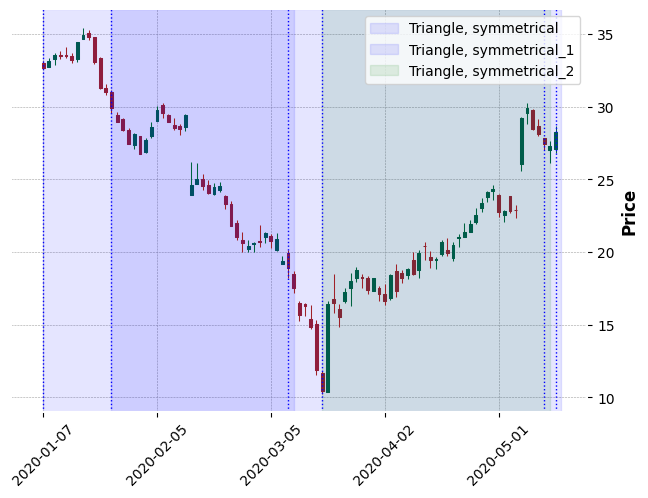

Processing test segments:   3%|▎         | 3/100 [04:20<2:23:35, 88.82s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  86 out of  86 | elapsed:    8.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  86 out of  86 | elapsed:    8.8s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done  86 out of  86 | elapsed:    9.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done  86 out of  86 | elapsed:    8.4s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

Double Bottom  :
    Clustered Windows :


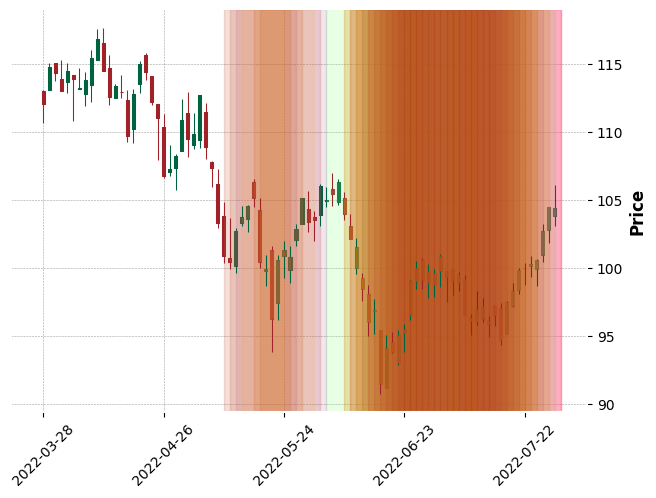

    Finalized Section :


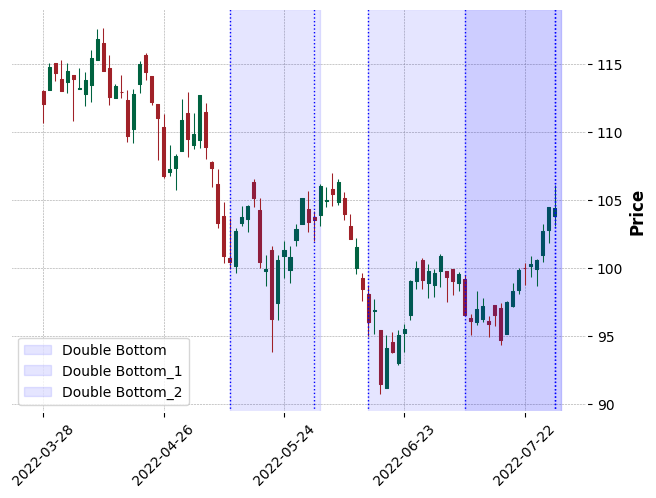

Double Top  :
    Clustered Windows :


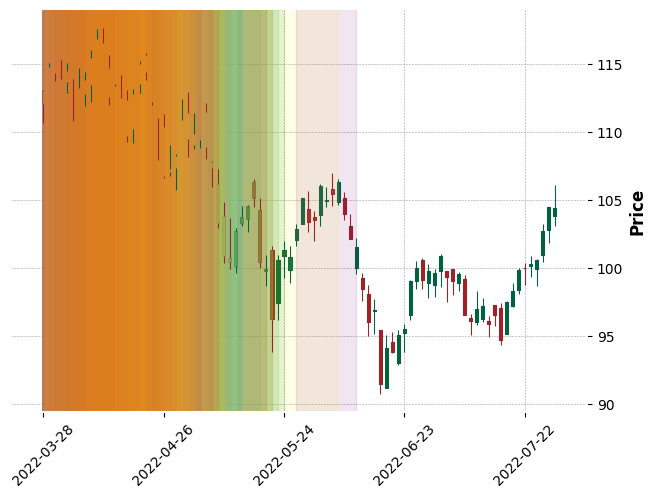

    Finalized Section :


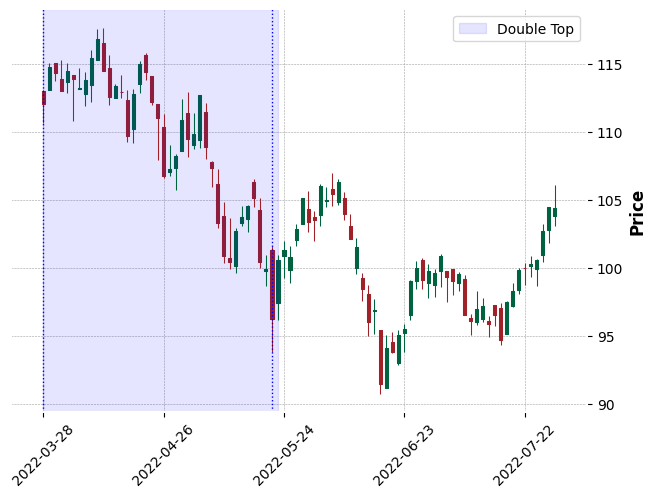

Head-and-shoulders bottom  :
    Clustered Windows :


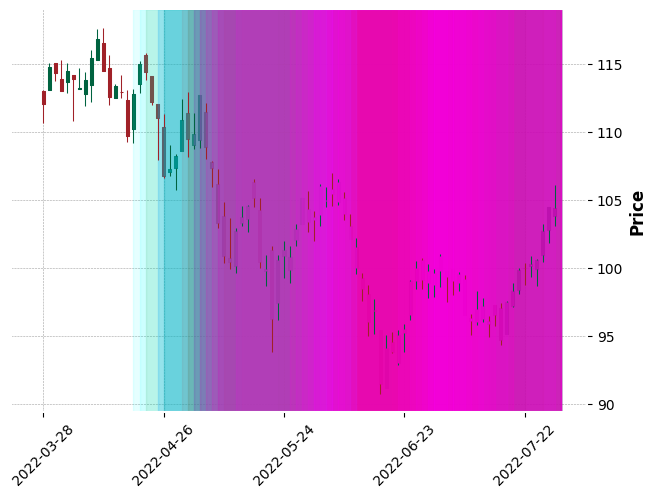

    Finalized Section :


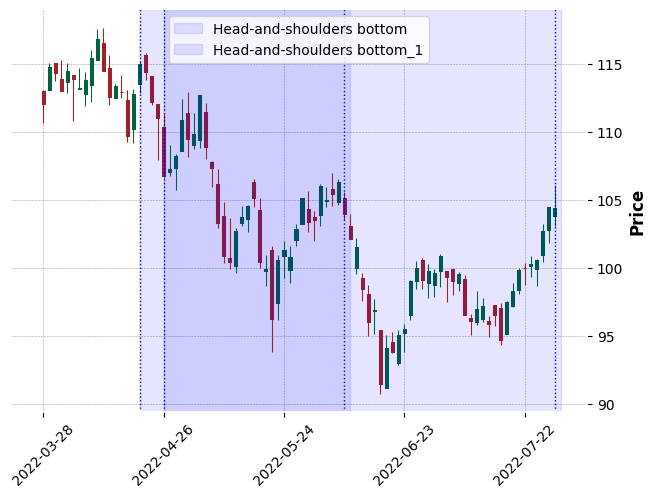

Head-and-shoulders top  :
    Clustered Windows :


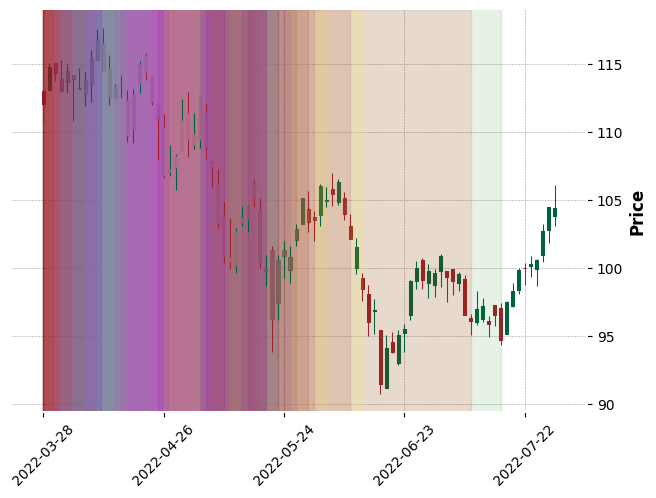

    Finalized Section :


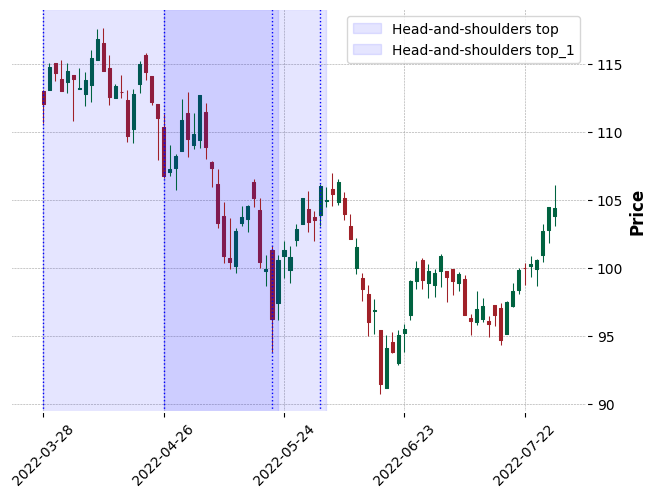

No Pattern  :
    Clustered Windows :


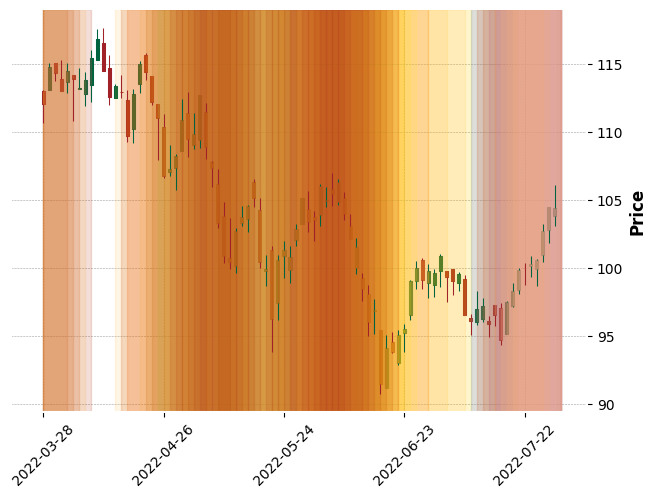

    Finalized Section :


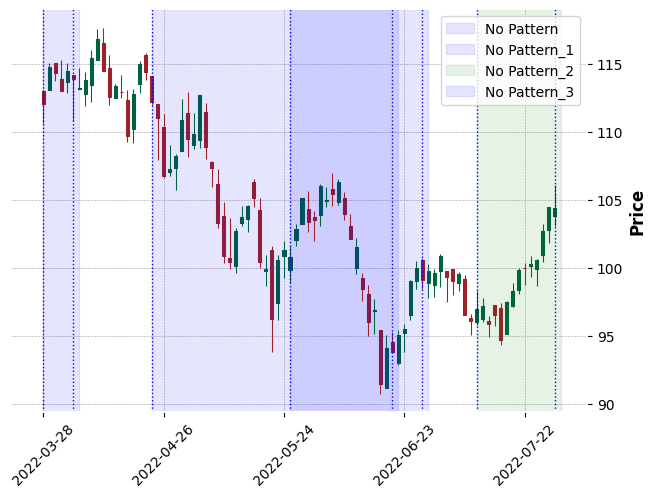

Triangle, symmetrical  :
    Clustered Windows :


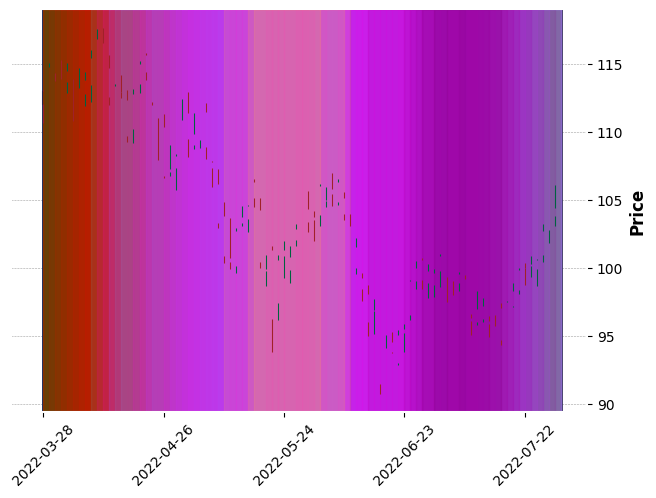

    Finalized Section :


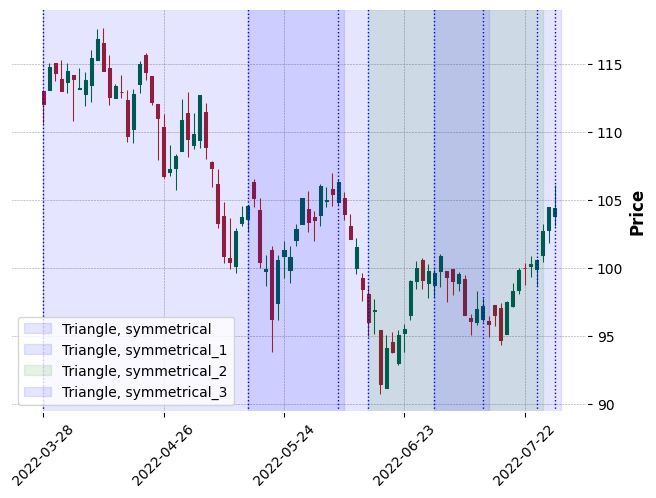

Processing test segments:   4%|▍         | 4/100 [05:50<2:22:39, 89.16s/it][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done  83 out of  83 | elapsed:    8.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  83 out of  83 | elapsed:    8.6s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done  83 out of  83 | elapsed:    8.9s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.8s
[Parallel(n_jobs=16)]: Done  83 out of  83 | elapsed:    8.3s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Paralle

Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    6.7s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    8.1s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    7.0s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.7s
[Parallel(n_jobs=16)]: Done  71 out of  71 | elapsed:    7.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=1

In [15]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict = {}
window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

plot_count = 4

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = -1
            
            for win_size_proportion in win_size_proportions:

                window_size = seg_len // win_size_proportion
                # print(f"Win size : {window_size}")
                if window_size < 10:
                    window_size = 10
                # elif window_size > 30:
                #     window_size = 30
                    
                # convert to int 
                window_size = int(window_size)
                if window_size in used_win_sizes:
                    continue
                used_win_sizes.append(window_size)
                
                    
                ohlc_data_segment = get_ohlc_data_segment(test_pattern_segment_wise, test_seg_id, path,group) 
                if ohlc_data_segment is None:
                    print("OHLC Data segment is empty")
                    continue   
                
                len_norm=False
                target_len = target_len
                
                # geet th efirst two words of the model_name 
                model_name_parts = model_name.split(' ')
                data_set_type = model_name_parts[0] + ' ' + model_name_parts[1]
                data_set_type
                
                if data_set_type == "Length Normed":
                    len_norm=True
                
                win_results_df = parallel_process_sliding_window(ohlc_data_segment, model, probability_threshold,stride, pattern_encoding_reversed,group,test_seg_id,window_size, padding_proportion, len_norm, target_len)
                
                if win_results_df is None:
                    print("Window results dataframe is empty")
                    continue
                win_results_df['Window_Size'] = window_size
                win_results_for_each_size.append(win_results_df)
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size)
                if cluster_labled_windows_df is None or interseced_clusters_df is None:
                    print("Clustered windows dataframe is empty")
                    continue
                cluster_labled_windows_df['Cluster'] = cluster_labled_windows_df['Cluster'].astype(int) + win_iteration
                win_iteration += 1
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]

                        for idx2 , row2 in intersecting_rows.iterrows():
                            # get the IOU of the intersecting rows
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])
                            if iou > 0.6 and row2['Window_Size'] > row['Window_Size']:
                                is_already_included = True
                                break
                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)
            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            if plot_count > 0:
                plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)    
                plot_count -= 1          
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
    
    
    
    located_patterns_and_other_info_dict[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df

    
    

In [16]:
# create Datasets/New_pattern_set_data/Adv_Method2_init/ folder if not exists
import os
if not os.path.exists("Datasets/New_pattern_set_data/Adv_Method2_init/"):
    os.makedirs("Datasets/New_pattern_set_data/Adv_Method2_init/")

# oop through the model names and get and save located_patterns_and_other_info_dfs and window_results_dfs to cs
for model_name in located_patterns_and_other_info_dict.keys():
    located_patterns_and_other_info_df = located_patterns_and_other_info_dict[model_name]
    window_results_df = window_results_dict[model_name]
    
    # save the dfs to csv
    located_patterns_and_other_info_df.to_csv(f"Datasets/New_pattern_set_data/Adv_Method2_init/located_patterns_and_other_info_{model_name}.csv", index=False)
    window_results_df.to_csv(f"Datasets/New_pattern_set_data/Adv_Method2_init/window_results_{model_name}.csv", index=False)

## Evaluate


In [17]:
from utils.eval import intersection_over_union , mean_abselute_error
from utils.formatAndPreprocessNewPatterns import get_pattern_list
chart_patterns = get_pattern_list()

In [18]:
test_patterns = pd.read_csv("Datasets/New_pattern_set_data/test_df.csv" )

test_patterns_without_no_pattern = test_patterns[test_patterns['Chart Pattern'] != "No Pattern"].copy()
# rename the Unnamed: 0 column to Instance
test_patterns_without_no_pattern.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
# rename the Unnamed: 0 column to Instance
selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)
selected_instances = selected_test_pattern_segment_wise_adv['Instance'].unique()
selected_test_patterns_without_no_pattern = test_patterns_without_no_pattern[test_patterns_without_no_pattern['Instance'].isin(selected_instances)]

/tmp/ipykernel_514448/3363097457.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_pattern_segment_wise_adv.rename(columns={'Unnamed: 0': 'Instance'}, inplace=True)


In [19]:

test_ids_rows_count_sum = selected_test_pattern_segment_wise_adv.groupby('Seg_ID').size().sum()

# per pattern row count in to a dict
pattern_row_count = {}
for pattern in chart_patterns:
    pattern_row_count[pattern] = selected_test_pattern_segment_wise_adv[selected_test_pattern_segment_wise_adv['Chart Pattern'] == pattern].shape[0]
    
pattern_row_count

{'Double Top': 34,
 'Double Bottom': 31,
 'Triangle, symmetrical': 14,
 'Head-and-shoulders top': 12,
 'Head-and-shoulders bottom': 15,
 'Flag, high and tight': 11,
 'No Pattern': 0}

In [20]:
from tqdm import tqdm
import pandas as pd
from utils.eval import get_model_eval_res

model_eval_results_dict = get_model_eval_res(located_patterns_and_other_info_dict,window_results_dict,selected_models_for_adv,selected_test_patterns_without_no_pattern)
model_eval_results_dict


 Selected model: Width Aug OHLC_mini_rocket_xgb
Processing row 471/117

Processing row 1064/117
 Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb
Processing row 1064/117

{'Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {'Double Top': 19,
   'Double Bottom': 27,
   'Triangle, symmetrical': 11,
   'Head-and-shoulders bottom': 9,
   'Flag, high and tight': 10,
   'Head-and-shoulders top': 10},
  'iou_for_each_properly_detected_pattern': {'Double Top': 7.8545253466280505,
   'Double Bottom': 13.182336197909096,
   'Triangle, symmetrical': 4.385380575721091,
   'Head-and-shoulders bottom': 4.108584368229271,
   'Flag, high and tight': 5.102078219886464,
   'Head-and-shoulders top': 5.211631662508456},
  'mae_for_each_properly_detected_pattern': {'Double Top': 352.5,
   'Double Bottom': 257.0,
   'Triangle, symmetrical': 242.0,
   'Head-and-shoulders bottom': 145.5,
   'Flag, high and tight': 257.5,
   'Head-and-shoulders top': 161.5}},
 'Length Normed + Width Aug OHLC_mini_rocket_xgb': {'number_of_properly_located_patterns': {'Double Top': 17,
   'Double Bottom': 18,
   'Triangle, symmetrical': 6,
   'Flag, high and tight': 3,
   '


==================== Model: Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.7350
Overall Precision: 0.0483
Overall F1 Score: 0.0875
Overall Mean Absolute Error: 16.4651
Overall Mean Intersection over Union: 0.4633

==================== Model: Length Normed + Width Aug OHLC_mini_rocket_xgb ====================
Overall Recall: 0.5043
Overall Precision: 0.0932
Overall F1 Score: 0.0902
Overall Mean Absolute Error: 15.6356
Overall Mean Intersection over Union: 0.4419

--- Comprehensive Model Comparison ---


/home/uomai/Candlestick-Chart-Pattern-Detection-FYP/utils/eval.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.88])  # Adjusted rect to account for title and legend


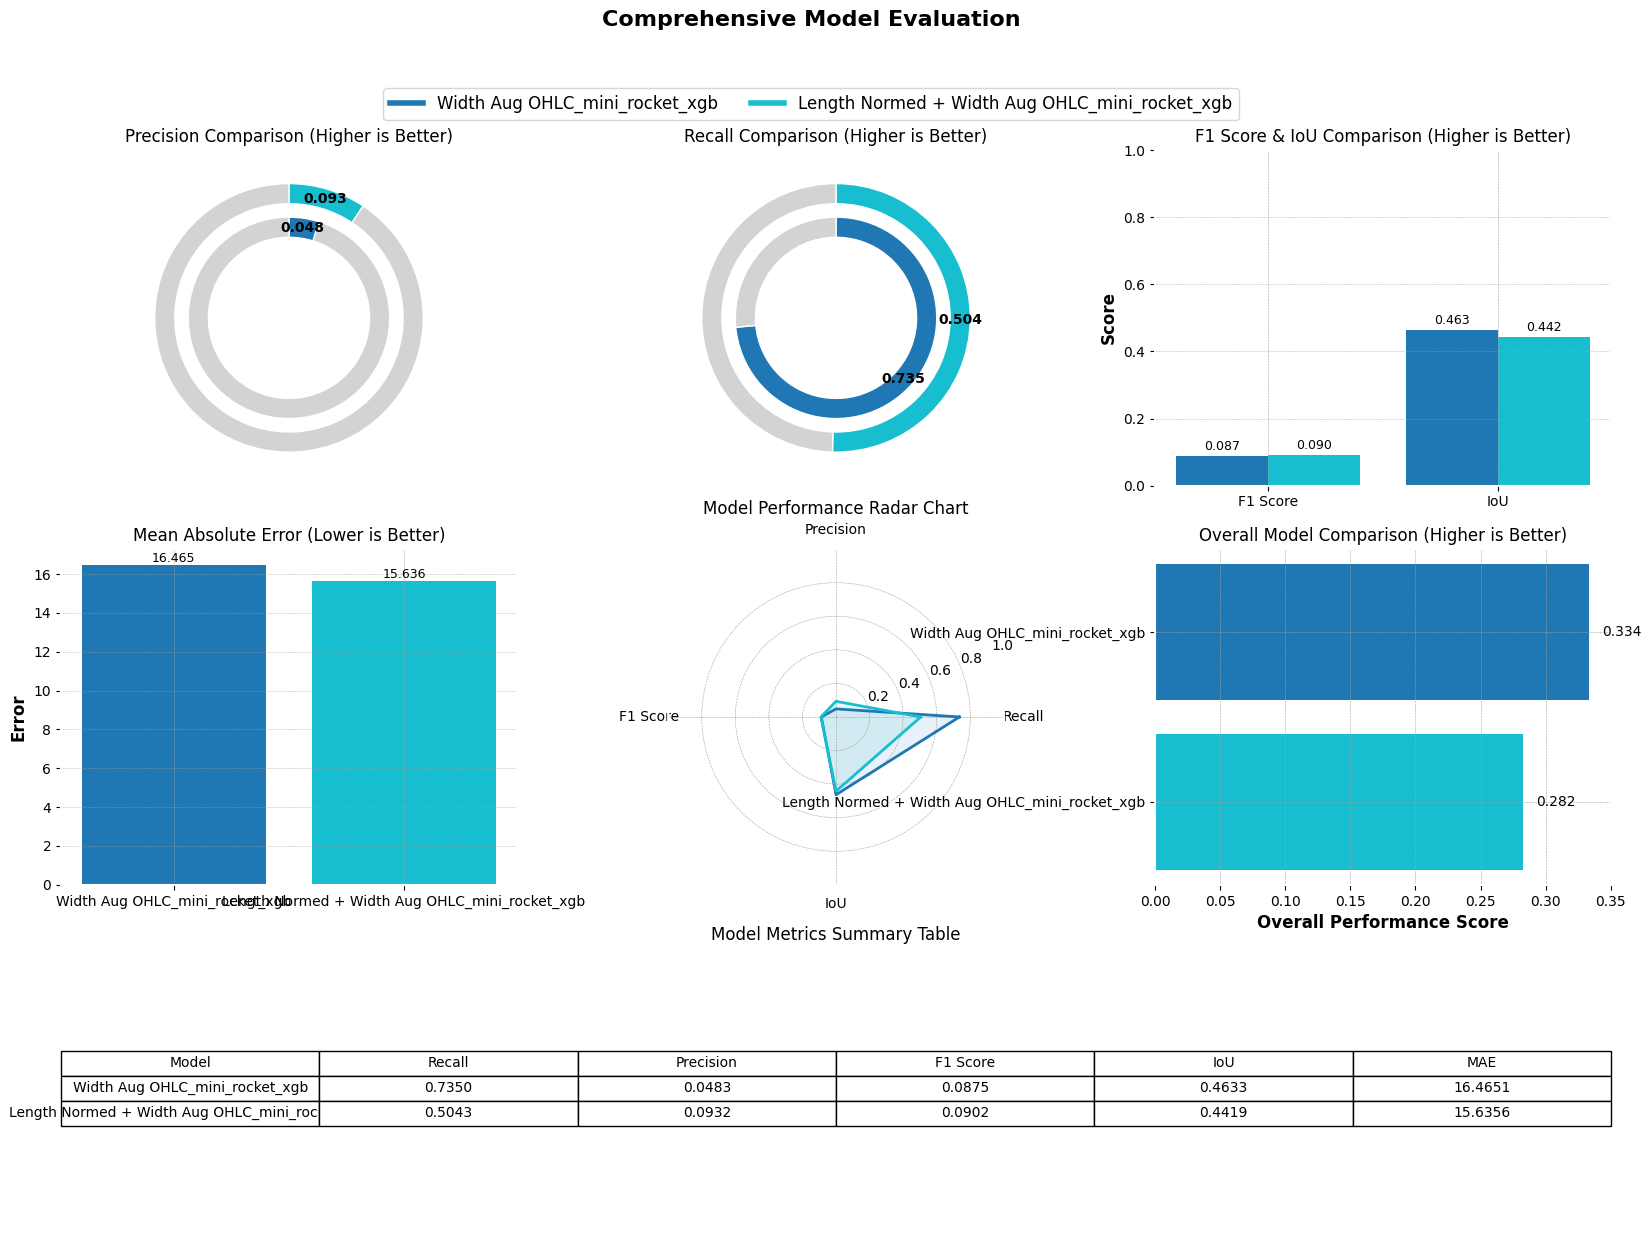

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from utils.eval import evaluate_all_models

all_metrics = evaluate_all_models(model_eval_results_dict, pattern_row_count, test_patterns, located_patterns_and_other_info_dict)
figure = all_metrics[1]

# Parameter Tune


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# load the pipelined model
import os
import joblib
from utils.FixedLengthTransformer import FixedLengthTransformer
# load the saved models from the Models directory
model_dir = "Models"
model_files = [f for f in os.listdir(model_dir) if f.endswith('.joblib')]
models = {}
for model_file in model_files:
    model_name = model_file.split('.')[0]
    models[model_name] = joblib.load(os.path.join(model_dir, model_file))
    
# print the model names
print("Available models:")
for model_name in models.keys():
    print(model_name)

selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb','Length Normed + Width Aug OHLC_mini_rocket_xgb']
# selected_models_for_adv = ['Width Aug OHLC_mini_rocket_xgb']

Available models:
Width Aug OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC_rocket_xgb
Width Aug OHLC_mini_rocket_xgb
Width Aug OHLC + traindata Aug_rocket_xgb
Length Normed + Width Aug OHLC_rocket_xgb
Plane OHLC + traindata Aug_mini_rocket_xgb
Width Aug OHLC + traindata Aug_multi_rocket_xgb
Width Aug OHLC_multi_rocket_xgb
Plane OHLC_rocket_xgb
Plane OHLC + traindata Aug_rocket_xgb
Plane OHLC_mini_rocket_xgb
Plane OHLC_multi_rocket_xgb
Length Normed + Width Aug OHLC_mini_rocket_xgb
Plane OHLC + traindata Aug_multi_rocket_xgb
Length Normed + Width Aug OHLC_multi_rocket_xgb
Length Normed OHLC_multi_rocket_xgb
Length Normed OHLC_mini_rocket_xgb
Length Normed OHLC_rocket_xgb


In [24]:
# load test_seg_ids_adv
import json

with open('Datasets/New_pattern_set_data/Adv_Method2_init/test_seg_ids_adv.json', 'r') as f:
    test_seg_ids_adv = json.load(f)

test_pattern_segment_wise = pd.read_csv("Datasets/New_pattern_set_data/test_patterns_large_segment_wise.csv")
selected_test_pattern_segment_wise_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)]
# selected_test_pattern_segment_wise_adv = test_pattern_segment_wise.copy()

test_ids_rows_count_sum_adv = test_pattern_segment_wise[test_pattern_segment_wise['Seg_ID'].isin(test_seg_ids_adv)].groupby('Seg_ID').size().sum()
test_ids_rows_count_sum_adv , len(test_seg_ids_adv)

(np.int64(124), 100)

In [25]:
# test_pattern_segment_wise convert Seg_Start , Seg_End , Start and End to datetime
test_pattern_segment_wise.loc[:, 'Seg_Start'] = pd.to_datetime(test_pattern_segment_wise['Seg_Start'])
test_pattern_segment_wise.loc[:, 'Seg_End'] = pd.to_datetime(test_pattern_segment_wise['Seg_End'])
test_pattern_segment_wise.loc[:, 'Start'] = pd.to_datetime(test_pattern_segment_wise['Start'])
test_pattern_segment_wise.loc[:, 'End'] = pd.to_datetime(test_pattern_segment_wise['End'])

In [26]:
# load the saved csv files to respective dictionaries
located_patterns_and_other_info_dict = {}
window_results_dict = {}

data_dir = "Datasets/New_pattern_set_data/Adv_Method2_init/"
for model_name in selected_models_for_adv:
    located_patterns_and_other_info_df = pd.read_csv(f"{data_dir}located_patterns_and_other_info_{model_name}.csv")
    window_results_df = pd.read_csv(f"{data_dir}window_results_{model_name}.csv")
    
    # convert Start,End and Seg_Start, Seg_End columns to datetime
    window_results_df ['Start'] = pd.to_datetime(window_results_df['Start'])
    window_results_df ['End'] = pd.to_datetime(window_results_df['End'])
    window_results_df['Seg_Start'] = pd.to_datetime(window_results_df['Seg_Start'])
    window_results_df['Seg_End'] = pd.to_datetime(window_results_df['Seg_End'])
    
    # convert Start,End,Seg_Start, Seg_End,Calc_Start, Calc_End columns to datetime
    located_patterns_and_other_info_df ['Start'] = pd.to_datetime(located_patterns_and_other_info_df['Start'])
    located_patterns_and_other_info_df ['End'] = pd.to_datetime(located_patterns_and_other_info_df['End'])
    located_patterns_and_other_info_df['Seg_Start'] = pd.to_datetime(located_patterns_and_other_info_df['Seg_Start'])
    located_patterns_and_other_info_df['Seg_End'] = pd.to_datetime(located_patterns_and_other_info_df['Seg_End'])
    located_patterns_and_other_info_df['Calc_Start'] = pd.to_datetime(located_patterns_and_other_info_df['Calc_Start'])
    located_patterns_and_other_info_df['Calc_End'] = pd.to_datetime(located_patterns_and_other_info_df['Calc_End'])
    
    located_patterns_and_other_info_dict [model_name] = located_patterns_and_other_info_df
    window_results_dict[model_name] = window_results_df
    
    
    

In [27]:
# window_size = 20
# win_size_proportion = 5
win_size_proportions = np.round(np.logspace(0, np.log10(20), num=10), 2).tolist()
# Example output: [1.0, 1.58, 2.5, 3.95, 6.25, 9.88, 15.63, 20.0]
padding_proportion = 0.6
stride = 1
probability_threshold = 0.0
# for len norm 
target_len = 30

eps=0.04 # in the dbscan clustering
min_samples=3 # in the dbscan clustering
win_width_proportion=10 # in the dbscan clustering from what amount to divide the width related feature

In [28]:



for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    
    i = 0
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = -1
            
            for win_size_proportion in win_size_proportions:

                window_size = seg_len // win_size_proportion
                # print(f"Win size : {window_size}")
                if window_size < 10:
                    window_size = 10
                # elif window_size > 30:
                #     window_size = 30
                    
                # convert to int 
                window_size = int(window_size)
                if window_size in used_win_sizes:
                    continue
                used_win_sizes.append(window_size)
                i+=1
    print(i)
                
                

Selected model: Width Aug OHLC_mini_rocket_xgb


Processing test segments:   0%|          | 0/100 [00:00<?, ?it/s]

Processing test segments: 100%|██████████| 100/100 [00:00<00:00, 537.93it/s]


826
Selected model: Length Normed + Width Aug OHLC_mini_rocket_xgb


Processing test segments: 100%|██████████| 100/100 [00:00<00:00, 540.03it/s]

826


In [29]:
window_results_df

,Seg_ID,Start,End,Symbol,Chart Pattern,Seg_Start,Seg_End,Probability,Window_Size
0,4,2024-10-25,2024-12-24,CW,Head-and-shoulders top,2024-10-25,2025-02-08,0.454861,106
1,4,2024-10-25,2024-12-26,CW,Head-and-shoulders top,2024-10-25,2025-02-08,0.431591,106
2,4,2024-10-25,2024-12-27,CW,Double Bottom,2024-10-25,2025-02-08,0.409910,106
3,4,2024-10-25,2024-12-30,CW,Double Bottom,2024-10-25,2025-02-08,0.384992,106
4,4,2024-10-25,2024-12-31,CW,Head-and-shoulders top,2024-10-25,2025-02-08,0.328212,106
...,...,...,...,...,...,...,...,...,...
71530,109,2022-10-20,2022-11-02,KMB,No Pattern,2022-06-15,2022-11-03,0.730928,10
71531,109,2022-10-21,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.934164,10
71532,109,2022-10-24,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.640614,10
71533,109,2022-10-25,2022-11-03,KMB,No Pattern,2022-06-15,2022-11-03,0.665064,10


In [30]:
# window_results_df get the number of unique  \Seg_Ids in window_results_df
window_results_df['Seg_ID'].nunique()

100

In [31]:
import sys

from tqdm import tqdm

from utils.formatAndPreprocessNewPatterns import get_reverse_pattern_encoding
from utils.functionalPatternLocateAndPlot import functional_pattern_filter_and_point_recognition
from utils.patternLocating import  get_ohlc_data_segment, parallel_process_sliding_window, prepare_dataset_for_cluster
from utils.functionalPatternLocateAndPlot import plot_pattern_groups_and_finalized_sections
from utils.patternLocating import cluster_windows
from utils.eval import intersection_over_union

located_patterns_and_other_info_dict_updated = {}
# window_results_dict = {}
pattern_encoding_reversed = get_reverse_pattern_encoding()
path = 'Datasets/OHLC data'

plot_count = 4

for model_name in selected_models_for_adv:
    print(f"Selected model: {model_name}")
    model = models[model_name]
    
    located_patterns_and_other_info_list = []
    window_results_list = []

    # for seg_id, group in tqdm(grouped, desc="Processing segments"):
        
    #     test_seg_id = seg_id  
    for test_seg_id in tqdm(test_seg_ids_adv, desc="Processing test segments"):
        # try :
            # plot_patterns_for_segment(test_seg_id    , test_pattern_segment_wise)
            grouped = test_pattern_segment_wise.groupby('Seg_ID')
            # Select a group
            group = grouped.get_group(test_seg_id)

            Seg_Start = group.iloc[0]['Seg_Start']
            Seg_End = group.iloc[0]['Seg_End']
            seg_len = (Seg_End - Seg_Start).days
            
            win_results_for_each_size = []
            located_patterns_and_other_info_for_each_size = []
            cluster_labled_windows_list = []
            
            used_win_sizes = []
            win_iteration = -1
            


            for win_results_df in window_results_dict[model_name].groupby('Window_Size'):
                # plot_sliding_steps(win_results_df ,ohlc_data_segment,probability_threshold ,test_seg_id)
                predicted_patterns = prepare_dataset_for_cluster(ohlc_data_segment, win_results_df)
                if predicted_patterns is None:
                    print("Predicted patterns dataframe is empty")
                # print("Predicted Patterns :",predicted_patterns)
                cluster_labled_windows_df , interseced_clusters_df = cluster_windows(predicted_patterns, probability_threshold, window_size , 
                if cluster_labled_windows_df is None or interseced_clusters_df is None:
                    print("Clustered windows dataframe is empty")
                    continue
                cluster_labled_windows_df['Cluster'] = cluster_labled_windows_df['Cluster'].astype(int) + win_iteration
                win_iteration += 1
                cluster_labled_windows_list.append(cluster_labled_windows_df)
                located_patterns_and_other_info = functional_pattern_filter_and_point_recognition(interseced_clusters_df)
                if located_patterns_and_other_info is None:
                    print("Located patterns and other info dataframe is empty")
                    continue
                # plot_pattern_groups_and_finalized_sections(located_patterns_and_other_info, cluster_labled_windows_df, test_seg_id)
                located_patterns_and_other_info['Window_Size'] = window_size
                
                located_patterns_and_other_info_for_each_size.append(located_patterns_and_other_info)
                
            located_patterns_and_other_info_for_each_size_df = pd.concat(located_patterns_and_other_info_for_each_size)
            win_results_for_each_size_df = pd.concat(win_results_for_each_size, ignore_index=True)
            window_results_list.append(win_results_for_each_size_df)
            
            # get the set of unique window sizes from located_patterns_and_other_info_for_each_size_df
            unique_window_sizes = located_patterns_and_other_info_for_each_size_df['Window_Size'].unique()
            unique_patterns = located_patterns_and_other_info_for_each_size_df['Chart Pattern'].unique()    
            
            # sort the unique_window_sizes descending order
            unique_window_sizes = np.sort(unique_window_sizes)[::-1]
            
            filtered_loc_pat_and_info_rows_list = []

            for chart_pattern in unique_patterns:    
                located_patterns_and_other_info_for_each_size_df_chart_pattern = located_patterns_and_other_info_for_each_size_df[located_patterns_and_other_info_for_each_size_df['Chart Pattern'] == chart_pattern]
                for win_size in unique_window_sizes:
                    located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern = located_patterns_and_other_info_for_each_size_df_chart_pattern[located_patterns_and_other_info_for_each_size_df_chart_pattern['Window_Size'] == win_size]
                    for idx , row in located_patterns_and_other_info_for_each_size_df_win_size_chart_pattern.iterrows():
                        start_date = row['Calc_Start']
                        end_date = row['Calc_End']
                        is_already_included = False
                        # check if there are any other rows that intersect with the start and end dates with the same chart pattern
                        intersecting_rows = located_patterns_and_other_info_for_each_size_df_chart_pattern[
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_Start'] <= end_date) &
                                                            (located_patterns_and_other_info_for_each_size_df_chart_pattern['Calc_End'] >= start_date)
                                                        ]

                        for idx2 , row2 in intersecting_rows.iterrows():
                            # get the IOU of the intersecting rows
                            iou = intersection_over_union(start_date, end_date, row2['Calc_Start'], row2['Calc_End'])
                            if iou > 0.6 and row2['Window_Size'] > row['Window_Size']:
                                is_already_included = True
                                break
                        if not is_already_included:
                            filtered_loc_pat_and_info_rows_list.append(row)
            
            # convert the filtered_loc_pat_and_info_rows_list to a dataframe
            filtered_loc_pat_and_info_df = pd.DataFrame(filtered_loc_pat_and_info_rows_list)
            located_patterns_and_other_info_list.append(filtered_loc_pat_and_info_df) 
            
            cluster_labled_windows_df_conc = pd.concat(cluster_labled_windows_list)
            if plot_count > 0:
                plot_pattern_groups_and_finalized_sections(filtered_loc_pat_and_info_df, cluster_labled_windows_df_conc, test_seg_id)    
                plot_count -= 1          
        # except:
        #     print("Error in segment ID: ",test_seg_id,"error : ",sys.exc_info()[0])
        #     continue

    located_patterns_and_other_info_final_df = pd.concat(located_patterns_and_other_info_list)
    window_results_all_df = pd.concat(window_results_list)
          
    located_patterns_and_other_info_dict_updated[model_name] = located_patterns_and_other_info_final_df
    window_results_dict[model_name] = window_results_all_df

SyntaxError: '(' was never closed (2811629870.py, line 55)

In [ ]:
window_results_dict

{}